# MalthusJAX Crossover Operators — Technical Overview & Guide

This notebook provides an **executable, interactive guide** to the `malthusjax.operators.crossover` package.

**Target audience**: Developers implementing custom crossover operators, extending existing operators, or understanding the three-tier crossover architecture.

**What you'll learn**:
- The **three-tier crossover architecture**: Kernel (Tier 1), Noise generation (Tier 2), Vectorized wrapper (Tier 3)
- **Mask semantics**: Per-element selection vs. gate-based selection
- **PRNG management** and static resource budgeting
- **XLA kernel fusion** for performance
- Built-in operators: UniformCrossover, BlendCrossover, SimulatedBinaryCrossover, SinglePointCrossover
- **Practical examples** with executable code
- **Injection mode** for noise materialization and debugging
- **Evosax integration** for compatibility with external algorithms

---

In [1]:
from typing import Any, cast

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

from malthusjax.core.genome.binary_genome import (
    BinaryGenomeConfig,
    BinaryPopulation,
)

# Import MalthusJAX genome and crossover modules
from malthusjax.core.genome.real_genome import (
    RealGenome,
    RealGenomeConfig,
    RealPopulation,
)
from malthusjax.operators.crossover import (
    BinaryUniformCrossover,
    RealUniformCrossover,
    SimulatedBinaryCrossover,
)
from malthusjax.operators.crossover import (
    BlendCrossover as RealBlendCrossover,
)

print(f"JAX version: {jax.__version__}")
print("✓ All imports successful")

JAX version: 0.10.0
✓ All imports successful


## 1. The Three-Tier Crossover Architecture

MalthusJAX crossover operators implement genetic recombination through three distinct tiers:

### Tier 1: Recombination Kernel (Pure Arithmetic)

**Purpose**: Combine two parent genomes deterministically using pre-generated noise/masks.

**Contract**: `_recombine_one(p1: G, p2: G, noise_data: Any, config: C) -> G`

- Takes single parent pair + noise mask
- Returns **single offspring** (vectorization handled by Tier 3)
- Pure arithmetic: no Python branching in hot path
- Example: `offspring = jnp.where(mask, p2.values, p1.values)`

### Tier 2: Noise/Mask Generation (RNG)

**Purpose**: Generate random masks or parameters for Tier 1.

**Contract**: `_generate_noise(keys: chex.PRNGKey, config: C) -> noise_data`

- Consumes fixed number of PRNG keys per operation
- Produces Bernoulli masks, uniform samples, or crossover points
- Sets explicit dtypes to avoid implicit type promotion
- Shaped to `config.shape`

### Tier 3: Vectorized Wrapper (Population-Level Orchestration)

**Purpose**: Orchestrate population-level crossover via nested vmap.

**Responsibilities**:
- Reshape keys to `(num_pairs, num_offspring, num_keys_per_atomic_op, 2)`
- Nested vmap: outer over parent pairs, inner over offspring per pair
- Fuse RNG generation + arithmetic via `_cross_fused()`
- Flatten offspring to 1-D via pair-major ordering (direct `reshape`)
- Return new population via `spawn_offspring()`

**Result**: XLA merges all operations into single kernel for maximal throughput.

## 2. Mask Semantics: Selection Patterns

### Pattern A: Per-Element Selection (UniformCrossover, SinglePointCrossover)

The mask is a **per-gene boolean vector**:
- `mask=False` → inherit from Parent 1
- `mask=True` → inherit from Parent 2

```python
offspring = jnp.where(mask, p2.values, p1.values)  # True -> p2, False -> p1
```

**Test conditions**:
- All-False mask → offspring == p1
- All-True mask → offspring == p2
- Mixed mask → correct per-gene inheritance

### Pattern B: Gate-Based Selection (BlendCrossover, SBX, BinomialCrossover)

The mask is a **0-D boolean gating decision**:
- `decision=False` → return Parent 1 unchanged
- `decision=True` → return computed/blended offspring

```python
offspring = jnp.where(decision, computed_values, p1.values)
```

**Key difference**: Not all offspring inherit from both parents. Some are unchanged copies of Parent 1.

**Test conditions**:
- gate=False → offspring == p1 (unchanged)
- gate=True → offspring == computed_values (blended or adapted)

## 3. Resource Mapping & Static RNG Budget

The `ResourceMap` computes RNG budget statically:

1. Each operator declares `num_keys_per_atomic_operation`:
   - UniformCrossover: 1 key (Bernoulli mask)
   - BlendCrossover: 2 keys (decision + blend values)
   - SBX: 2 keys (decision + distortion)

2. Total budget: `num_pairs × num_offspring × num_keys_per_atomic_operation`

3. Keys pre-allocated and reshaped to `(num_pairs, num_offspring, num_keys, 2)`

**Benefits**:
- Deterministic key slicing across all operators
- Reproducible randomness
- Static memory allocation

In [2]:
# Example 1: UniformCrossover - Per-Element Selection
# Demonstrate basic crossover operation

# Setup
config = RealGenomeConfig(shape=(5,), bounds=(0.0, 1.0), dtype=jnp.float32)
key = jr.PRNGKey(42)

# Create parent populations
p1_pop = RealPopulation.init_random(key, config, size=4)
p2_pop = RealPopulation.init_random(jr.fold_in(key, 1), config, size=4)

print("=== Parent Populations ===")
print(f"Parent 1 genes shape: {p1_pop.genes.values.shape}")
print(f"Parent 2 genes shape: {p2_pop.genes.values.shape}")
print(f"\nParent 1 sample: {p1_pop.genes.values[0]}")
print(f"Parent 2 sample: {p2_pop.genes.values[0]}")

# Create crossover operator
crossover = RealUniformCrossover(
    num_offspring=2,  # 2 offspring per parent pair
    crossover_rate=0.6,  # 60% chance per gene
)
crossover = crossover.set_input_length(4)  # 4 parent pairs

# Allocate PRNG keys
# UniformCrossover uses 1 key per operation
# Total: 4 pairs × 2 offspring × 1 key = 8 keys
num_keys = crossover.num_keys((4,))
all_keys = jr.split(key, num_keys)

print("\n=== Crossover Setup ===")
print("Num offspring per pair: 2")
print("Crossover rate: 0.6")
print(f"Total PRNG keys needed: {num_keys} (4 pairs × 2 offspring × 1 key)")

# Perform crossover
offspring_pop = crossover(all_keys, p1_pop, p2_pop, config)

print("\n=== Offspring ===")
print(f"Offspring population size: {len(offspring_pop)}")
print(f"Offspring genes shape: {offspring_pop.genes.values.shape}")
print(f"\nOffspring 0 (from pair 0): {offspring_pop.genes.values[0]}")
print(f"Offspring 1 (from pair 0): {offspring_pop.genes.values[1]}")
print("\nOffspring inherit from both parents (mixed genes)")

=== Parent Populations ===
Parent 1 genes shape: (4, 5)
Parent 2 genes shape: (4, 5)

Parent 1 sample: [0.5302608  0.31336212 0.90153027 0.6983329  0.6180656 ]
Parent 2 sample: [0.22840178 0.9359591  0.573305   0.11875105 0.2504102 ]

=== Crossover Setup ===
Num offspring per pair: 2
Crossover rate: 0.6
Total PRNG keys needed: 8 (4 pairs × 2 offspring × 1 key)

=== Offspring ===
Offspring population size: 8
Offspring genes shape: (8, 5)

Offspring 0 (from pair 0): [0.22840178 0.9359591  0.90153027 0.6983329  0.6180656 ]
Offspring 1 (from pair 0): [0.5302608  0.31336212 0.573305   0.11875105 0.2504102 ]

Offspring inherit from both parents (mixed genes)


## 4. Practical Example: Blend Crossover (Gate-Based Selection)

BlendCrossover (BLX-α) demonstrates **gate-based selection**:

- Computes weighted average + random extension of parent range
- With probability (1 - `crossover_rate`), returns Parent 1 unchanged
- With probability `crossover_rate`, returns blended offspring

This is different from per-element selection: entire offspring is either computed or unchanged.

In [3]:
# Example 2: BlendCrossover - Gate-Based Selection

# Setup same parents
config = RealGenomeConfig(shape=(5,), bounds=(0.0, 1.0), dtype=jnp.float32)
key = jr.PRNGKey(123)

p1_pop = RealPopulation.init_random(key, config, size=4)
p2_pop = RealPopulation.init_random(jr.fold_in(key, 1), config, size=4)

# Create BlendCrossover operator (gate-based)
blend_crossover = RealBlendCrossover(
    num_offspring=2,
    crossover_rate=0.7,  # Probability of actually blending
    alpha=0.5,  # Blend extension parameter
)
blend_crossover = blend_crossover.set_input_length(4)

# BlendCrossover uses 2 keys (decision + blend values)
num_keys = blend_crossover.num_keys((4,))
all_keys = jr.split(key, num_keys)

print("=== BlendCrossover (Gate-Based Selection) ===")
print("Num offspring per pair: 2")
print("Crossover rate (probability to blend): 0.7")
print("Alpha (extension parameter): 0.5")
print(f"Total PRNG keys needed: {num_keys} (4 pairs × 2 offspring × 2 keys)")

# Perform blend crossover
offspring_pop = blend_crossover(all_keys, p1_pop, p2_pop, config)

print("\n=== Offspring ===")
print(f"Offspring population size: {len(offspring_pop)}")

# Analyze blending
print("\nSample parent pair:")
print(f"Parent 1: {p1_pop.genes.values[0]}")
print(f"Parent 2: {p2_pop.genes.values[0]}")
print(f"Offspring 0: {offspring_pop.genes.values[0]}")
print(f"Offspring 1: {offspring_pop.genes.values[1]}")

# Check if offspring might be outside parent range
p1_sample = p1_pop.genes.values[0]
p2_sample = p2_pop.genes.values[0]
offspring_sample = offspring_pop.genes.values[0]

min_parent = jnp.minimum(p1_sample, p2_sample)
max_parent = jnp.maximum(p1_sample, p2_sample)

outside_lower = jnp.any(offspring_sample < min_parent)
outside_upper = jnp.any(offspring_sample > max_parent)

print("\nBlend characteristic:")
print("Some offspring may extend outside parent range (BLX-α feature)")
print(f"Min parent values: {min_parent}")
print(f"Max parent values: {max_parent}")

=== BlendCrossover (Gate-Based Selection) ===
Num offspring per pair: 2
Crossover rate (probability to blend): 0.7
Alpha (extension parameter): 0.5
Total PRNG keys needed: 16 (4 pairs × 2 offspring × 2 keys)

=== Offspring ===
Offspring population size: 8

Sample parent pair:
Parent 1: [0.3117367  0.17159796 0.03793263 0.381706   0.5196842 ]
Parent 2: [0.11082065 0.16402435 0.99125993 0.43647528 0.5111238 ]
Offspring 0: [0.09750822 0.16117828 0.11555773 0.4080484  0.52187306]
Offspring 1: [0.40908134 0.16888067 0.88039404 0.40806887 0.5102694 ]

Blend characteristic:
Some offspring may extend outside parent range (BLX-α feature)
Min parent values: [0.11082065 0.16402435 0.03793263 0.381706   0.5111238 ]
Max parent values: [0.3117367  0.17159796 0.99125993 0.43647528 0.5196842 ]


## 5. Simulated Binary Crossover (SBX)

SBX (Simulated Binary Crossover) is a **gate-based operator** that:

1. Decides whether to cross each pair (probability = `crossover_rate`)
2. If crossing: applies polynomial distribution-based distortion
3. If not crossing: returns Parent 1 unchanged

**Parameters**:
- `eta`: Distribution index (higher = more exploitation, closer to parents)
- Typical range: η=10-30
- Default: η=20 (parent-centric)

In [4]:
# Example 3: SimulatedBinaryCrossover (SBX)

config = RealGenomeConfig(shape=(5,), bounds=(-5.0, 5.0), dtype=jnp.float32)
key = jr.PRNGKey(456)

p1_pop = RealPopulation.init_random(key, config, size=3)
p2_pop = RealPopulation.init_random(jr.fold_in(key, 2), config, size=3)

# Create SBX operator
sbx_crossover = SimulatedBinaryCrossover(
    num_offspring=1,  # Typically 1 offspring per pair for SBX
    crossover_rate=0.8,
    eta=20.0,  # Distribution index (exploitation)
)
sbx_crossover = sbx_crossover.set_input_length(3)

# SBX uses 2 keys (decision + distortion)
num_keys = sbx_crossover.num_keys((3,))
all_keys = jr.split(key, num_keys)

print("=== Simulated Binary Crossover (SBX) ===")
print("Num offspring per pair: 1")
print("Crossover rate: 0.8")
print("Eta (distribution index): 20.0")
print(f"Phenotype bounds: {config.bounds}")
print(f"Total PRNG keys: {num_keys}")

# Perform SBX
offspring_pop = sbx_crossover(all_keys, p1_pop, p2_pop, config)

print("\n=== Offspring ===")
print(f"Offspring size: {len(offspring_pop)}")
print("\nSample crossover result:")
print(f"Parent 1: {p1_pop.genes.values[0]}")
print(f"Parent 2: {p2_pop.genes.values[0]}")
print(f"Offspring: {offspring_pop.genes.values[0]}")

# Verify bounds
offspring_values = offspring_pop.genes.values
min_bound, max_bound = config.bounds
within_bounds = jnp.all((offspring_values >= min_bound) & (offspring_values <= max_bound))
print(f"\nAll offspring within bounds: {within_bounds}")

=== Simulated Binary Crossover (SBX) ===
Num offspring per pair: 1
Crossover rate: 0.8
Eta (distribution index): 20.0
Phenotype bounds: (-5.0, 5.0)
Total PRNG keys: 9

=== Offspring ===
Offspring size: 3

Sample crossover result:
Parent 1: [ 3.604343    2.2390091  -3.750707    1.1393905   0.41835666]
Parent 2: [-0.24453282  3.3701718  -1.98125    -3.8433754  -1.3825798 ]
Offspring: [ 3.604343    2.2390091  -3.750707    1.1393905   0.41835666]

All offspring within bounds: True


## 6. Binary Crossover: Single-Point & Uniform

### Single-Point Crossover
- Randomly select one crossover point
- Swap segments: Parent 1 → [0:point], Parent 2 → [point:]
- Preserves physical adjacency of genes

### Uniform Crossover (Binary)
- Independently select each bit from Parent 1 or 2 with probability `crossover_rate`
- Higher disruption, better exploration
- No adjacency preservation

In [5]:
# Example 4: Binary Uniform Crossover

config = BinaryGenomeConfig(shape=(10,))
key = jr.PRNGKey(789)

p1_pop = BinaryPopulation.init_random(key, config, size=10)
p2_pop = BinaryPopulation.init_random(jr.fold_in(key, 3), config, size=10)

# Create binary uniform crossover
binary_uc = BinaryUniformCrossover(
    num_offspring=2,
    crossover_rate=0.5,  # 50% chance per bit
)
binary_uc = binary_uc.set_input_length(10)

# Binary crossover uses 1 key (Bernoulli mask)
num_keys = binary_uc.num_keys((10,))
all_keys = jr.split(key, num_keys)

print("=== Binary Uniform Crossover ===")
print("Genome shape: 10 bits")
print("Num parent pairs: 2")
print("Num offspring per pair: 2")
print("Crossover rate: 0.5")
print(f"Total PRNG keys: {num_keys}")

# Perform crossover
offspring_pop = binary_uc(all_keys, p1_pop, p2_pop, config)

print("\n=== Results ===")
print(f"Offspring size: {len(offspring_pop)}")

# Show example
print(f"\nParent 1: {p1_pop.genes.values[0]}")
print(f"Parent 2: {p2_pop.genes.values[0]}")
print(f"Offspring 1: {offspring_pop.genes.values[0]}")
print(f"Offspring 2: {offspring_pop.genes.values[1]}")

# Count inheritance
p1_bits = jnp.sum(offspring_pop.genes.values[0] == p1_pop.genes.values[0])
p2_bits = jnp.sum(offspring_pop.genes.values[0] == p2_pop.genes.values[0])
print(
    f"\nOffspring 1 inheritance:\n"
    f"  From Parent 1: {p1_bits}/10 bits\n"
    f"  From Parent 2: {p2_bits}/10 bits"
)

=== Binary Uniform Crossover ===
Genome shape: 10 bits
Num parent pairs: 2
Num offspring per pair: 2
Crossover rate: 0.5
Total PRNG keys: 20

=== Results ===
Offspring size: 20

Parent 1: [0 0 0 1 1 0 1 1 0 1]
Parent 2: [1 1 1 0 0 0 0 0 1 1]
Offspring 1: [0 0 0 0 0 0 0 0 0 1]
Offspring 2: [0 0 0 0 1 0 1 0 1 1]

Offspring 1 inheritance:
  From Parent 1: 6/10 bits
  From Parent 2: 6/10 bits


## 7. XLA Kernel Fusion & Performance

### Why Tier 3 Matters

The three-tier design enables **XLA kernel fusion**:

1. **Tier 2** generates RNG masks
2. **Tier 1** applies recombination (pure arithmetic)
3. **XLA** fuses both into **single kernel**

### Pair-Major Flattening (Phase 3 Optimization)

Offspring are flattened in **pair-major order** using direct `reshape` (no transpose):

```
Before flatten: (num_pairs, num_offspring, genome_shape)
After flatten:  (num_pairs * num_offspring, genome_shape)

Ordering:
  [pair0_offspring0, pair0_offspring1,
   pair1_offspring0, pair1_offspring1,
   ...]
```

**Benefit**: Direct `reshape` avoids transpose, eliminating physical data copy and enabling XLA fusion.

## 8. Injection Mode: Full Noise Materialization

While standard mode generates noise lazily during computation, **injection mode** materializes all noise upfront.

**Trade-off**:
- **Standard mode**: Memory efficient, lazy generation
- **Injection mode**: All noise materialized, explicit control, debugging-friendly

**Best for**:
- Debugging crossover behavior
- Exact reproducibility studies
- Ablation experiments
- Small populations

## 9. Operator Selection Guide

| Problem Type | Operator | Parameters | Use When |
|--------------|----------|------------|----------|
| **Binary/Combinatorial** | Uniform Crossover | rate=0.5 | High disruption, good exploration |
| **Binary/Building Blocks** | Single-Point | default | Preserves adjacency, exploitation |
| **Real/Independent Genes** | Uniform Crossover | rate=0.6 | Simple per-gene mixing |
| **Real/Exploration** | Blend (BLX-α) | α=0.5 | Explores outside parental range |
| **Real/Exploitation** | SBX | η=20-30 | Parent-centric, distribution-aware |
| **Differential Evolution** | Binomial | rate=0.5 | Directional, mutant-biased |

### Decision Tree

1. **Binary genomes?** → Use Uniform or Single-Point Crossover
2. **Real-valued genomes?**
   - Early stage / exploration phase? → Blend (BLX-α)
   - Late stage / exploitation phase? → SBX with high η (20-30)
   - Need fine control per gene? → Uniform Crossover
3. **Categorical/permutation genomes?** → Use domain-specific operators

## 10. Developer Checklist for Custom Operators

When implementing a new crossover operator:

### Core Implementation
- [ ] Define `num_keys_per_atomic_operation`
- [ ] Implement `_generate_noise(keys, config)` → returns masked/parameters of shape `config.shape`
- [ ] Implement `_recombine_one(p1, p2, noise_data, config)` → returns **single offspring**
- [ ] Use deterministic selection: `jnp.where(mask, p2.values, p1.values)`

### Mask Semantics (Choose One)
- [ ] **Per-element selection**: each gene independently from one parent
  - Test: all-False → offspring==p1, all-True → offspring==p2
- [ ] **Gate-based selection**: entire offspring computed or unchanged
  - Test: False gate → offspring==p1, True gate → offspring==computed

### Type Safety
- [ ] Explicitly set `dtype=config.dtype` in noise generation
- [ ] Mark static attributes as `pytree_node=False`
- [ ] Return `chex.Numeric` (JAX arrays, not Python scalars)

### PRNG Handling
- [ ] Extract keys correctly: `k1, k2 = keys[0], keys[1]`
- [ ] Handle both new-style (scalar) and legacy (uint32[2]) PRNG via `typed_keys` parameter

### Testing
- [ ] Test shape/dtype of `_generate_noise()`
- [ ] Test boundary conditions (masks all-False, all-True)
- [ ] Verify crossover rate empirically
- [ ] Check offspring ordering (pair-major flattening)

=== Crossover Visualization ===
Parent 1: [2. 2.]
Parent 2: [8. 8.]
Num replicate pairs: 20
Offspring per pair: 3
Total offspring: 60


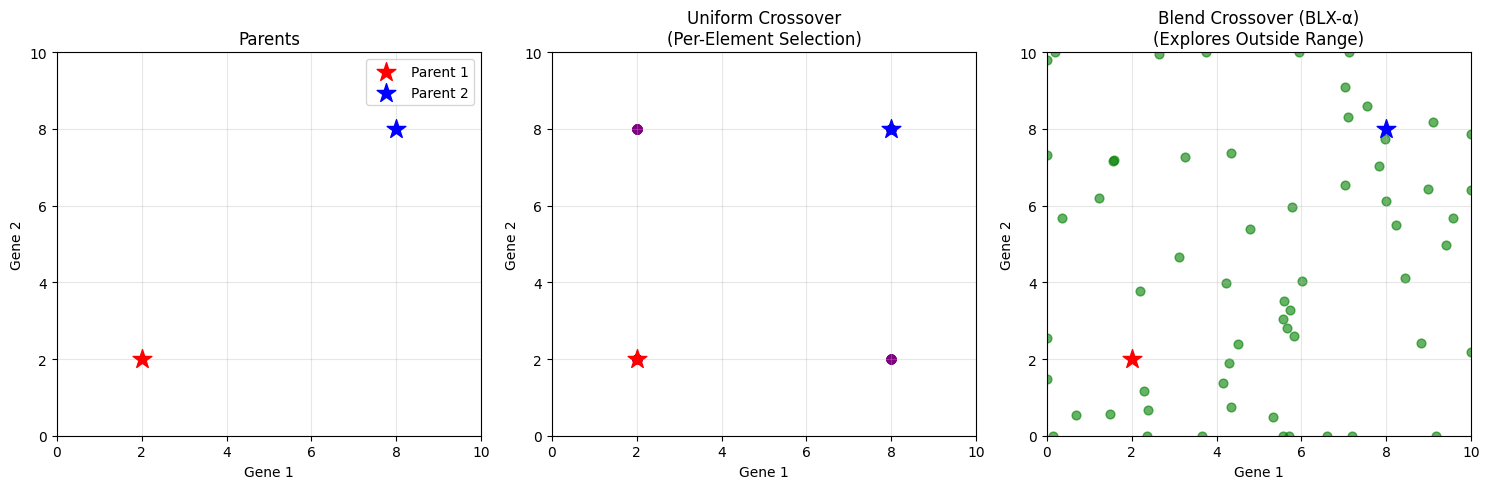


✓ Visualization complete


In [6]:
# Example 5: Visualizing Crossover Effects

# Create two simple parent genomes
config = RealGenomeConfig(shape=(2,), bounds=(0.0, 10.0))
key = jr.PRNGKey(999)

# Parent 1: cluster around (2, 2)
p1_values = jnp.array([[2.0, 2.0]])
p1_pop = RealPopulation.init_random(key, config, size=1)
p1_pop = cast(
    RealPopulation,
    cast(Any, p1_pop).replace(
        genes=cast(RealGenome, cast(Any, p1_pop.genes).replace(values=p1_values))
    ),
)

# Parent 2: cluster around (8, 8)
p2_values = jnp.array([[8.0, 8.0]])
p2_pop = RealPopulation.init_random(key, config, size=1)
p2_pop = cast(
    RealPopulation,
    cast(Any, p2_pop).replace(
        genes=cast(RealGenome, cast(Any, p2_pop.genes).replace(values=p2_values))
    ),
)

# Create many offspring with different operators
num_replicate_pairs = 20
num_offspring_per_pair = 3

# Expand parents
p1_expanded = cast(
    RealPopulation,
    cast(Any, p1_pop).replace(
        genes=cast(
            RealGenome,
            cast(Any, p1_pop.genes).replace(values=jnp.tile(p1_values, (num_replicate_pairs, 1))),
        )
    ),
)

p2_expanded = cast(
    RealPopulation,
    cast(Any, p2_pop).replace(
        genes=cast(
            RealGenome,
            cast(Any, p2_pop.genes).replace(values=jnp.tile(p2_values, (num_replicate_pairs, 1))),
        )
    ),
)

# Uniform Crossover
uc = RealUniformCrossover(num_offspring=num_offspring_per_pair, crossover_rate=0.5)
uc = uc.set_input_length(num_replicate_pairs)
# Calculate keys: num_pairs * num_offspring * keys_per_op
num_keys_uc = num_replicate_pairs * num_offspring_per_pair * uc.num_keys_per_atomic_operation
keys_uc = jr.split(key, num_keys_uc)
offspring_uc = uc(keys_uc, p1_expanded, p2_expanded, config)

# Blend Crossover
blend = RealBlendCrossover(num_offspring=num_offspring_per_pair, alpha=0.5, crossover_rate=1.0)
blend = blend.set_input_length(num_replicate_pairs)
num_keys_blend = num_replicate_pairs * num_offspring_per_pair * blend.num_keys_per_atomic_operation
keys_blend = jr.split(jr.fold_in(key, 2), num_keys_blend)
offspring_blend = blend(keys_blend, p1_expanded, p2_expanded, config)

print("=== Crossover Visualization ===")
print(f"Parent 1: {p1_values[0]}")
print(f"Parent 2: {p2_values[0]}")
print(f"Num replicate pairs: {num_replicate_pairs}")
print(f"Offspring per pair: {num_offspring_per_pair}")
print(f"Total offspring: {len(offspring_uc)}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot parents
axes[0].scatter(
    p1_values[:, 0], p1_values[:, 1], color="red", s=200, marker="*", label="Parent 1", zorder=5
)
axes[0].scatter(
    p2_values[:, 0], p2_values[:, 1], color="blue", s=200, marker="*", label="Parent 2", zorder=5
)
axes[0].set_xlim(0, 10)
axes[0].set_ylim(0, 10)
axes[0].set_xlabel("Gene 1")
axes[0].set_ylabel("Gene 2")
axes[0].set_title("Parents")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot uniform crossover offspring
axes[1].scatter(
    offspring_uc.genes.values[:, 0],
    offspring_uc.genes.values[:, 1],
    color="purple",
    alpha=0.6,
    label="Offspring",
    s=40,
)
axes[1].scatter(p1_values[0, 0], p1_values[0, 1], color="red", s=200, marker="*", zorder=5)
axes[1].scatter(p2_values[0, 0], p2_values[0, 1], color="blue", s=200, marker="*", zorder=5)
axes[1].set_xlim(0, 10)
axes[1].set_ylim(0, 10)
axes[1].set_xlabel("Gene 1")
axes[1].set_ylabel("Gene 2")
axes[1].set_title("Uniform Crossover\n(Per-Element Selection)")
axes[1].grid(True, alpha=0.3)

# Plot blend crossover offspring
axes[2].scatter(
    offspring_blend.genes.values[:, 0],
    offspring_blend.genes.values[:, 1],
    color="green",
    alpha=0.6,
    label="Offspring",
    s=40,
)
axes[2].scatter(p1_values[0, 0], p1_values[0, 1], color="red", s=200, marker="*", zorder=5)
axes[2].scatter(p2_values[0, 0], p2_values[0, 1], color="blue", s=200, marker="*", zorder=5)
axes[2].set_xlim(0, 10)
axes[2].set_ylim(0, 10)
axes[2].set_xlabel("Gene 1")
axes[2].set_ylabel("Gene 2")
axes[2].set_title("Blend Crossover (BLX-α)\n(Explores Outside Range)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Visualization complete")

## 11. Summary & Key Takeaways

### Three-Tier Paradigm

1. **Tier 1 (Pure Arithmetic)**: `_recombine_one(p1, p2, noise, config) → offspring`
   - Deterministic per-gene or gate-based selection
   - No randomness or branching

2. **Tier 2 (RNG)**: `_generate_noise(keys, config) → noise_data`
   - Produces Bernoulli masks or blend parameters
   - Shape matches `config.shape`; explicit dtype

3. **Tier 3 (Vectorization)**: `BaseCrossover.__call__(all_keys, p1, p2, config) → offspring_pop`
   - Nested vmaps over pairs and offspring
   - Pair-major flattening for XLA fusion

### Benefits

- ✅ **XLA kernel fusion**: RNG + arithmetic merged into single kernel
- ✅ **Reproducibility**: Deterministic key slicing and nested vmaps
- ✅ **Scalability**: Static resource budgeting enables device-agnostic deployment
- ✅ **Developer simplicity**: Implement only Tier 1 + 2; Tier 3 automatic

### Mask Semantics

- **Per-element**: Each gene independently selected from P1 or P2
- **Gate-based**: Entire offspring computed or unchanged (depends on 0-D gate)

### Operator Selection

- **Binary + Exploration**: Uniform Crossover
- **Binary + Exploitation**: Single-Point Crossover
- **Real + Exploration**: Blend (BLX-α)
- **Real + Exploitation**: SBX (high η)
- **Differential Evolution**: Binomial

---

## 12. Next Steps

- **Implement custom operators**: Follow checklist in Section 10; test Tier 1/2 independently
- **Integrate with engines**: Use crossover with GA, DE, PSO from MalthusJAX
- **Profile performance**: Measure XLA fusion speedup with JAX profiling tools
- **Explore Evosax integration**: Use `EvosaxUniformCrossoverWrapper` for compatibility
- **Adjust parameters**: Tune crossover rates and operator-specific parameters (α, η) for your problem

---